In [14]:
import sys
import os
sys.path.append(os.path.abspath(".."))

note to self: aha! Die assen zijn de latitudes en longitudes op basis van wgs84. Nederland valt dus ongeveer/ precies in het bereik:
Min Latitude: 50.750° N
Max Latitude: 53.555° N
Min Longitude: 3.358° E
Max Longitude: 7.227° E

In [15]:
from pathlib import Path
import geopandas as gpd
import pandas as pd
import logging
import matplotlib.pyplot as plt
import rioxarray as rxr
import numpy as np

from src.logging_config import setup_logging
from src.utils import ensure_dir, check_raster, summarize_dataarray, load_config
from src.raster_ops import merge_tiles, read_raster_match
from src.netcdf_ops import extract_monthly_mean, extract_ssrd_may_process
from src.estk_ops import clip_and_reproject_estk
from src.npp import compute_npp

setup_logging() 


In [17]:
cfg = load_config("../src/config.yaml")
output_dir = Path(cfg["paths"]["output_dir"])
ensure_dir(output_dir)

provinces = gpd.read_file(cfg["paths"]["province_shapefile"])
gelderland = provinces[provinces["PV_NAAM"].str.contains("Gelderland", case=False)]

# gelderland.plot()


In [18]:

lai_tiles = [Path(cfg["paths"]["LAI_UGT_path"]), Path(cfg["paths"]["LAI_UFT_path"])]
lai_merged_path = Path(cfg["outputs"]["lai_merged"])

In [33]:
merged_lai = merge_tiles(
    tile_paths=lai_tiles,
    boundary=gelderland.to_crs(cfg["crs"]["target"]),
    target_crs=cfg["crs"]["target"],
    out_path=lai_merged_path,
)
check_raster(lai_merged_path, expected_crs=cfg["crs"]["target"])

2025-10-20 13:12:33 [INFO] src.raster_ops: Loading raster ../data/LAI_FAPAR_temporal_filled/LAI_T31UFT_2022-05-10_filled_temporal.tiff
2025-10-20 13:12:35 [INFO] src.raster_ops: Reprojecting clipped raster to EPSG:32631
2025-10-20 13:12:37 [INFO] src.raster_ops: Loading raster ../data/LAI_FAPAR_temporal_filled/LAI_T31UFT_2022-05-10_filled_temporal.tiff
2025-10-20 13:12:39 [INFO] src.raster_ops: Reprojecting clipped raster to EPSG:32631
2025-10-20 13:12:44 [INFO] src.raster_ops: Saving merged raster to ../data/NPP_processed_inputs/output_LAI_UTM31N.tif
2025-10-20 13:12:45 [INFO] src.utils: output_LAI_UTM31N.tif — Size: 449.4 MB | CRS: EPSG:32631 | Bounds: BoundingBox(left=637303.3115018645, bottom=5733800.013178326, right=763243.3115018645, top=5822990.013178326)


In [21]:
# lai = rxr.open_rasterio(lai_merged_path).squeeze()

# lai_data = lai.values.copy()
# mask_zero = lai_data == 0  # True where value = 0
# mask_nan = np.isnan(lai_data)  # True where value is NaN

# cmap = plt.cm.viridis.copy()  # Or any colormap you like
# cmap.set_under("lightgray")   # For zero values
# cmap.set_bad("white")         # For NaNs

# plot_data = lai_data.copy()
# plot_data[mask_zero] = -1e-6  # Anything below actual min will trigger 'under'

# plt.figure(figsize=(10, 8))
# im = plt.imshow(plot_data, cmap=cmap, vmin=0.001, vmax=np.nanmax(lai_data))
# plt.colorbar(im, label="LAI")
# plt.title("Merged LAI with zeros in gray")
# plt.show()


In [22]:
# plt.figure(figsize=(10, 10))
# plt.imshow(merged_lai, cmap='viridis')
# plt.colorbar(label='LAI')
# plt.title('Merged LAI Raster')
# # plt.show()

In [23]:
# stats = summarize_dataarray(merged_lai)
# for k, v in stats.items():
#     print(f"{k}: {v}")

In [34]:
fapar_tiles = [Path(cfg["paths"]["FAPAR_UGT_path"]), Path(cfg["paths"]["FAPAR_UFT_path"])]
fapar_merged_path = Path(cfg["outputs"]["fapar_merged"])

merged_fapar = merge_tiles(
    tile_paths=fapar_tiles,
    boundary=gelderland.to_crs(cfg["crs"]["target"]),
    target_crs=cfg["crs"]["target"],
    scale_factor=cfg["scaling"]["FAPAR"],
    out_path=fapar_merged_path,
)
check_raster(fapar_merged_path, expected_crs=cfg["crs"]["target"])

2025-10-20 13:12:51 [INFO] src.raster_ops: Loading raster ../data/LAI_FAPAR_temporal_filled/FAPAR_T31UFT_2022-05-10_filled_temporal.tiff


2025-10-20 13:12:55 [INFO] src.raster_ops: Reprojecting clipped raster to EPSG:32631
2025-10-20 13:12:56 [INFO] src.raster_ops: Loading raster ../data/LAI_FAPAR_temporal_filled/FAPAR_T31UGS_2022-05-10_filled_temporal.tiff
2025-10-20 13:12:57 [INFO] src.raster_ops: Reprojecting clipped raster to EPSG:32631
2025-10-20 13:12:59 [INFO] src.raster_ops: Saving merged raster to ../data/NPP_processed_inputs/output_FAPAR_UTM31N.tif
2025-10-20 13:13:00 [INFO] src.utils: output_FAPAR_UTM31N.tif — Size: 449.4 MB | CRS: EPSG:32631 | Bounds: BoundingBox(left=637303.3115018645, bottom=5733800.013178326, right=763243.3115018645, top=5822990.013178326)


In [ ]:
# plt.figure(figsize=(10, 10))
# plt.imshow(merged_fapar, cmap='viridis')
# plt.colorbar(label='FAPAR')
# plt.title('Merged FAPAR Raster')
# plt.show()

In [25]:
stats = summarize_dataarray(merged_fapar)
for k, v in stats.items():
    print(f"{k}: {v}")


min: 0.0
max: 0.019500000402331352
mean: 0.0032564899884164333
std: 0.005763223394751549
zero_count: 78967593
nan_count: 0
total_count: 112325886
nonzero_count: 33358293


In [26]:
gelderland_wgs84 = gelderland.to_crs("EPSG:4326")
bbox = gelderland_wgs84.total_bounds  
bbox_coords = {
    "lon_min": float(bbox[0]),
    "lon_max": float(bbox[2]),
    "lat_min": float(bbox[1]),
    "lat_max": float(bbox[3]),
}

In [27]:
temp_nc_path = Path(cfg["paths"]["temp_nc_path"])
temp_out_path = Path(cfg["outputs"]["temperature"])

extract_monthly_mean(
    nc_path=temp_nc_path,
    varname="TEMP",
    bbox_coords=bbox_coords,
    time_slice=cfg["npp"]["month_slice"],
    out_crs=cfg["crs"]["target"],
    out_path=temp_out_path,
)
check_raster(temp_out_path, expected_crs=cfg["crs"]["target"])


2025-10-20 13:12:00 [INFO] src.netcdf_ops: Selecting time slice 2022-05-01 to 2022-05-31 from ../data/NPP_inputs/Temps/single_level_2m_daily_mean_temp_2022_NL_ERA5.nc


2025-10-20 13:12:00 [INFO] src.netcdf_ops: Wrote raster to ../data/NPP_processed_inputs/temperature_Gelderland.tif
2025-10-20 13:12:00 [INFO] src.utils: temperature_Gelderland.tif — Size: 0.0 MB | CRS: EPSG:32631 | Bounds: BoundingBox(left=626913.5250109878, bottom=5719222.62178713, right=765030.0100936119, top=5837608.180429379)


In [28]:
ssrd_nc_path = Path(cfg["paths"]["ssrd_nc_path"])
ssrd_out_path = Path(cfg["outputs"]["ssrd"])

extract_ssrd_may_process(
    nc_path=ssrd_nc_path,
    varname="ssrd",
    bbox_coords=bbox_coords,
    time_slice=cfg["npp"]["month_slice"],
    out_crs=cfg["crs"]["target"],
    out_path=ssrd_out_path,
)
check_raster(ssrd_out_path, expected_crs=cfg["crs"]["target"])


2025-10-20 13:12:01 [INFO] src.netcdf_ops: Processed and saved SSRD to ../data/NPP_processed_inputs/ssrd_Gelderland.tif
2025-10-20 13:12:01 [INFO] src.utils: ssrd_Gelderland.tif — Size: 0.0 MB | CRS: EPSG:32631 | Bounds: BoundingBox(left=640609.5431240719, bottom=5736087.826350521, right=755546.7451127283, top=5831868.828007735)


In [29]:
estk_full_path = Path(cfg["paths"]["estk_full_path"])
estk_clipped_path = Path(cfg["estk"]["clipped_path"])
estk_reprojected_path = Path(cfg["estk"]["reprojected_path"])

clip_and_reproject_estk(
    estk_raster_path=estk_full_path,
    boundary_gdf=gelderland,
    clipped_raster_path=estk_clipped_path,
    reprojected_raster_path=estk_reprojected_path,
    target_crs=cfg["crs"]["target"],
)
check_raster(estk_reprojected_path, expected_crs=cfg["crs"]["target"])


2025-10-20 13:12:01 [INFO] src.estk_ops: Opening ESTK raster: ../data/NPP_inputs/ESTK_kaarten/NL_2022_10m.tif
2025-10-20 13:12:01 [INFO] src.estk_ops: Masking ESTK raster with boundary polygon
2025-10-20 13:12:03 [INFO] src.estk_ops: Saving clipped ESTK raster to ../data/NPP_processed_inputs/ESTK_Gelderland.tif
2025-10-20 13:12:03 [INFO] src.estk_ops: Reprojecting clipped raster to EPSG:32631
2025-10-20 13:12:05 [INFO] src.estk_ops: Saving reprojected ESTK raster to ../data/NPP_processed_inputs/ESTK_Gelderland_32631.tif
2025-10-20 13:12:06 [INFO] src.estk_ops: Completed ESTK clipping and reprojection
2025-10-20 13:12:06 [INFO] src.utils: ESTK_Gelderland_32631.tif — Size: 118.9 MB | CRS: EPSG:32631 | Bounds: BoundingBox(left=634880.1402805636, bottom=5733224.9038243145, right=764152.7573115675, top=5825180.992101532)


In [30]:
conversion_table = pd.read_excel(cfg["paths"]["conversion_table_path"], engine="openpyxl")
conversion_table.columns = conversion_table.columns.str.strip()
conversion_table = conversion_table.set_index("Pixelwaarde")
conversion_table.head()
#FIXME: The max values are too low thats what is broken, need to decide what other implementation is possible. Maybe check copernicus. 

,ESTK omschrijving,MODIS LC class,eps_max,SLA,Leaf_resp_base,Root_resp_base,Root_Leaf_ratio,Wood_resp_base,Wood_Leaf_ratio,T_max,T_min
Pixelwaarde,,,,,,,,,,,
1,Productiebos,6,0.000962,14.1,0.00604,0.00519,1.2,0.00397,0.182,8.31,-8
2,Akkerbouw_reg,1,0.001044,30.4,0.00980,0.00819,2.0,0.00000,0.000,12.02,-8
3,Ov_nat_grasland,2,0.000860,37.5,0.00980,0.00819,2.6,0.00000,0.000,12.02,-8
4,Groenvoorziening,7,0.001051,21.5,0.00778,0.00519,1.1,0.00371,0.203,9.50,-7
7,Infra_groen,4,0.001281,9.0,0.00869,0.00519,1.0,0.00436,0.079,8.61,-8


2025-10-20 13:13:00 [INFO] src.npp: Loading rasters for NPP computation
2025-10-20 13:13:00 [INFO] src.npp: Converting temperature from Kelvin to Celsius
2025-10-20 13:13:00 [INFO] src.npp: Aligning rasters to LAI grid


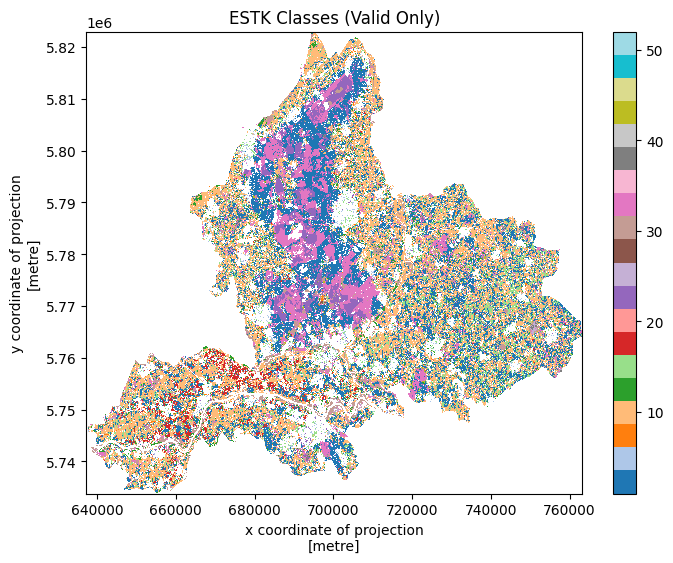

2025-10-20 13:13:44 [INFO] src.npp: Processing 30 valid ESTK classes for NPP
2025-10-20 13:16:58 [INFO] src.npp: NPP raster saved to ../NPP_outputs/NPP_Gelderland_May2022.tif
2025-10-20 13:16:58 [INFO] src.utils: NPP_Gelderland_May2022.tif — Size: 898.7 MB | CRS: EPSG:32631 | Bounds: BoundingBox(left=637303.3115018645, bottom=5733800.013178326, right=763243.3115018645, top=5822990.013178326)


In [35]:
npp_output_path = Path(cfg["outputs"]["npp"])

npp_raster = compute_npp(
    lai_path=lai_merged_path,
    fapar_path=fapar_merged_path,
    temp_path=temp_out_path,
    ssrd_path=ssrd_out_path,
    estk_path=estk_reprojected_path,
    conversion_df=conversion_table,
    output_path=npp_output_path,
)

check_raster(npp_output_path, expected_crs=cfg["crs"]["target"])


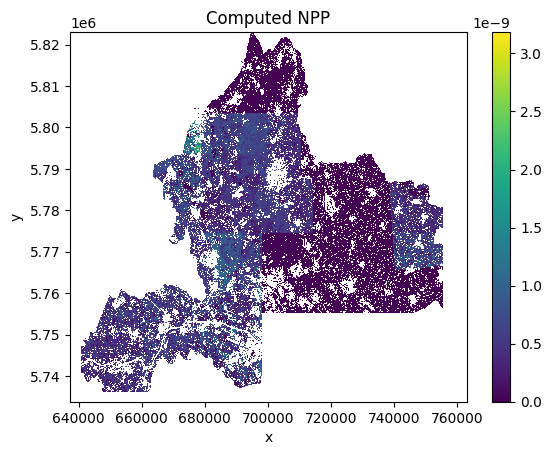

In [36]:
npp_raster.plot(cmap="viridis")
plt.title("Computed NPP")
plt.show()

In [39]:
stats = summarize_dataarray(npp_raster)
for k, v in stats.items():
    print(f"{k}: {v}")

min: -0.0
max: 3.1834223377732507e-09
mean: 3.1481208186065044e-10
std: 3.273303381737329e-10
zero_count: 12415003
nan_count: 76429322
total_count: 112325886
nonzero_count: 99910883


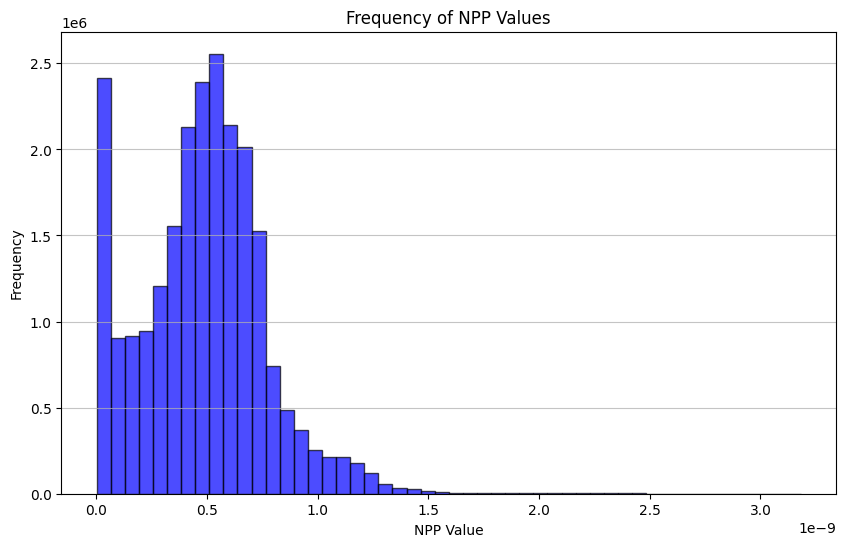

In [40]:
npp_values = npp_raster.values.flatten()
npp_values = npp_values[~np.isnan(npp_values) & (npp_values != 0)]  # Filter out NaNs and zeros
plt.figure(figsize=(10, 6))
plt.hist(npp_values, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.title('Frequency of NPP Values')
plt.xlabel('NPP Value')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()


In [ ]:
npp_raster